# ASH_COATED_OSMIUM EMA Mean-Reversion Visualization

This notebook visualizes an EMA-based mean-reversion signal for `ASH_COATED_OSMIUM` using the three round-1 price files.

It does four things:
- loads and cleans the quote snapshots,
- builds a short-horizon EMA fair value,
- defines a mean-reversion signal as `EMA - mid_price`,
- plots the price, EMA, signal, and forward move relationship.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

PRICE_FILES = [
    'prices_round_1_day_-2.csv',
    'prices_round_1_day_-1.csv',
    'prices_round_1_day_0.csv',
]

EMA_SPAN = 200
ENTRY_THRESHOLD = 4.0
FUTURE_HORIZON = 20


In [2]:
def load_prices(file_names: list[str]) -> pd.DataFrame:
    frames = []
    for file_name in file_names:
        day = int(file_name.split('_day_')[1].split('.csv')[0])
        frame = pd.read_csv(Path(file_name), sep=';')
        frame['day'] = day
        frames.append(frame)
    return pd.concat(frames, ignore_index=True)


prices = load_prices(PRICE_FILES)
ash = prices.loc[prices['product'] == 'ASH_COATED_OSMIUM'].copy()
ash = ash.sort_values(['day', 'timestamp']).reset_index(drop=True)

# Replace empty-book mid prices with NaN, then fill locally within each day.
ash.loc[ash['mid_price'] == 0, 'mid_price'] = np.nan
ash['mid_price'] = ash.groupby('day')['mid_price'].transform(lambda s: s.ffill().bfill())

ash['bid'] = ash.groupby('day')['bid_price_1'].transform(lambda s: s.ffill().bfill())
ash['ask'] = ash.groupby('day')['ask_price_1'].transform(lambda s: s.ffill().bfill())
ash['spread'] = ash['ask'] - ash['bid']

# Build a continuous time index across days for easier plotting and EMA computation.
day_offset = {day: idx * 1_000_000 for idx, day in enumerate(sorted(ash['day'].unique()))}
ash['global_time'] = ash['day'].map(day_offset) + ash['timestamp']

ash.head()


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,bid,ask,spread,global_time
0,-2,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,"10,010.000",25.000,NaN,NaN,NaN,NaN,"10,010.000",0.000,"9,992.000","10,010.000",18.000,0
1,-2,100,ASH_COATED_OSMIUM,"9,992.000",15.000,NaN,NaN,NaN,NaN,"10,008.000",15.000,"10,011.000",20.000,NaN,NaN,"10,000.000",0.000,"9,992.000","10,008.000",16.000,100
2,-2,200,ASH_COATED_OSMIUM,"9,992.000",15.000,"9,989.000",30.000,NaN,NaN,"10,008.000",15.000,"10,010.000",30.000,NaN,NaN,"10,000.000",0.000,"9,992.000","10,008.000",16.000,200
3,-2,300,ASH_COATED_OSMIUM,"9,992.000",13.000,"9,989.000",26.000,NaN,NaN,"10,008.000",13.000,"10,010.000",26.000,NaN,NaN,"10,000.000",0.000,"9,992.000","10,008.000",16.000,300
4,-2,400,ASH_COATED_OSMIUM,"9,992.000",15.000,NaN,NaN,NaN,NaN,"10,008.000",15.000,"10,010.000",20.000,NaN,NaN,"10,000.000",0.000,"9,992.000","10,008.000",16.000,400


In [3]:
ash['ema'] = ash['mid_price'].ewm(span=EMA_SPAN, adjust=False).mean()
ash['signal'] = ash['ema'] - ash['mid_price']
ash['future_move'] = ash['mid_price'].shift(-FUTURE_HORIZON) - ash['mid_price']

ash['long_entry'] = ash['signal'] > ENTRY_THRESHOLD
ash['short_entry'] = ash['signal'] < -ENTRY_THRESHOLD

summary = pd.DataFrame(
    {
        'metric': [
            'rows',
            'mean mid',
            'std mid',
            'mean spread',
            'std signal',
            'corr(signal, future_move)',
            'long entries',
            'short entries',
        ],
        'value': [
            len(ash),
            ash['mid_price'].mean(),
            ash['mid_price'].std(),
            ash['spread'].mean(),
            ash['signal'].std(),
            ash[['signal', 'future_move']].dropna().corr().iloc[0, 1],
            int(ash['long_entry'].sum()),
            int(ash['short_entry'].sum()),
        ],
    }
)

summary


,metric,value
0,rows,"30,000.000"
1,mean mid,"10,000.206"
2,std mid,5.349
3,mean spread,16.173
4,std signal,3.277
5,"corr(signal, future_move)",0.540
6,long entries,"2,412.000"
7,short entries,"2,396.000"


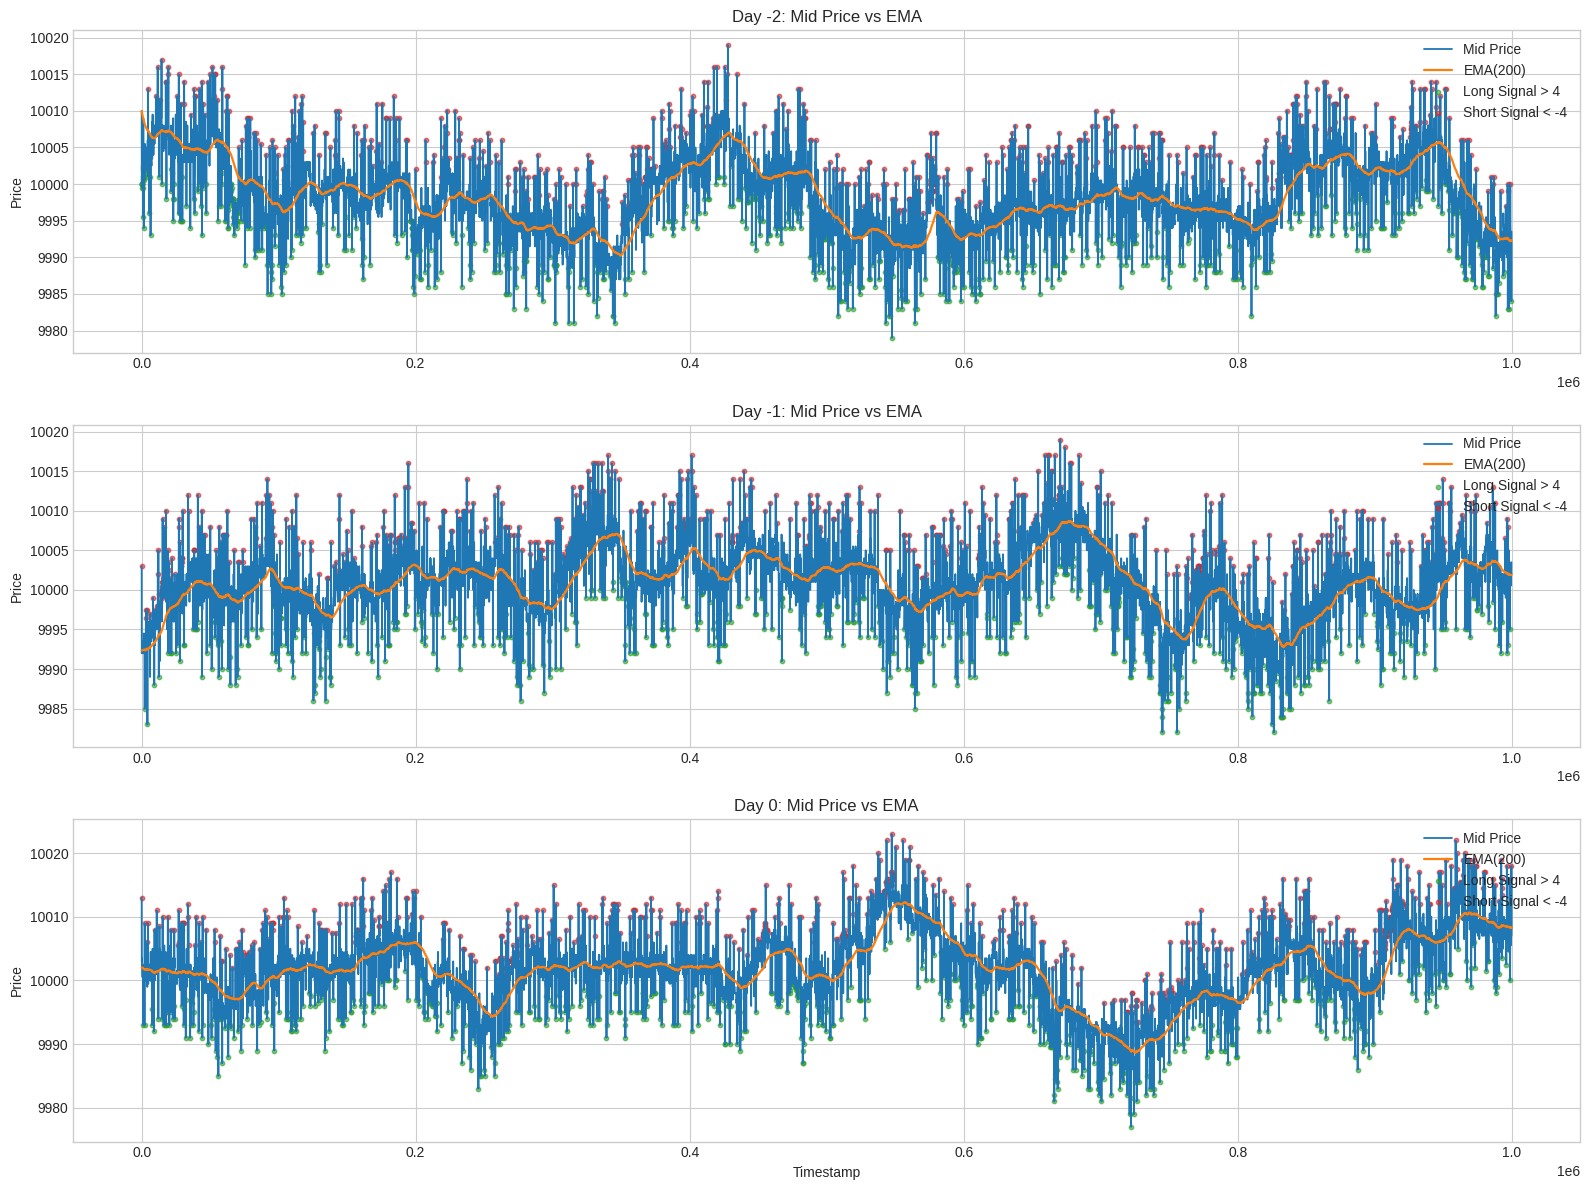

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=False)

for ax, day in zip(axes, sorted(ash['day'].unique())):
    day_df = ash.loc[ash['day'] == day].copy()
    x = day_df['timestamp']

    ax.plot(x, day_df['mid_price'], label='Mid Price', color='tab:blue', linewidth=1.3)
    ax.plot(x, day_df['ema'], label=f'EMA({EMA_SPAN})', color='tab:orange', linewidth=1.6)

    ax.scatter(
        day_df.loc[day_df['long_entry'], 'timestamp'],
        day_df.loc[day_df['long_entry'], 'mid_price'],
        s=10,
        color='tab:green',
        alpha=0.6,
        label=f'Long Signal > {ENTRY_THRESHOLD:g}',
    )
    ax.scatter(
        day_df.loc[day_df['short_entry'], 'timestamp'],
        day_df.loc[day_df['short_entry'], 'mid_price'],
        s=10,
        color='tab:red',
        alpha=0.6,
        label=f'Short Signal < -{ENTRY_THRESHOLD:g}',
    )

    ax.set_title(f'Day {day}: Mid Price vs EMA')
    ax.set_ylabel('Price')
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Timestamp')
plt.tight_layout()
plt.show()


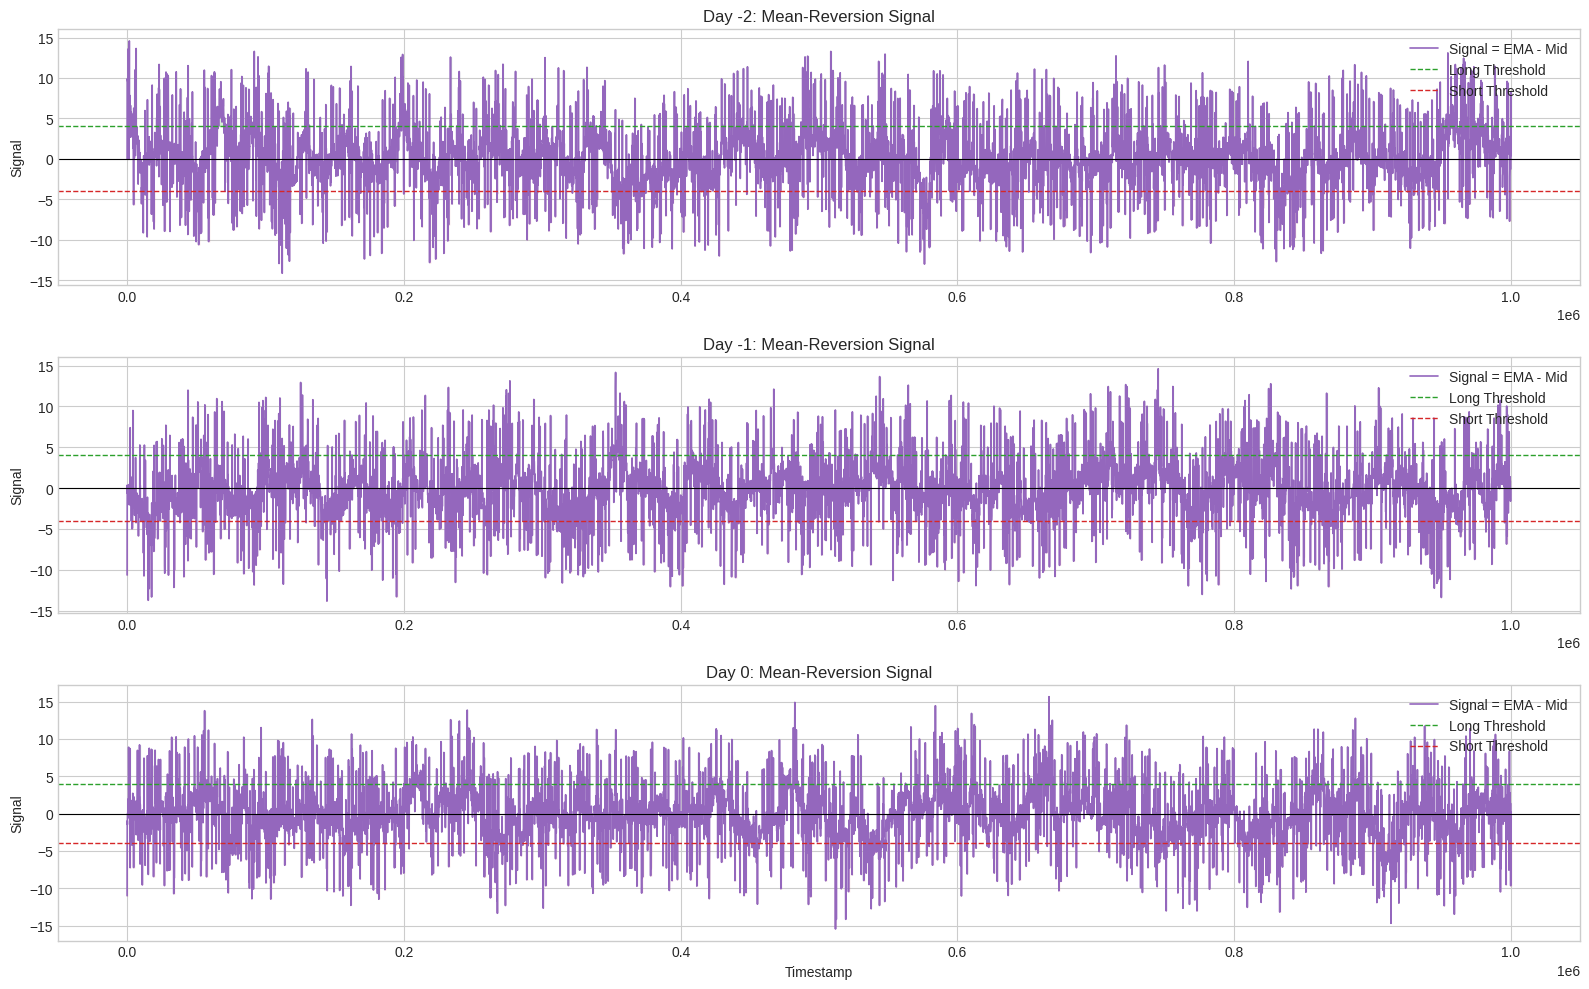

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=False)

for ax, day in zip(axes, sorted(ash['day'].unique())):
    day_df = ash.loc[ash['day'] == day].copy()
    x = day_df['timestamp']

    ax.plot(x, day_df['signal'], color='tab:purple', linewidth=1.2, label='Signal = EMA - Mid')
    ax.axhline(ENTRY_THRESHOLD, color='tab:green', linestyle='--', linewidth=1.0, label='Long Threshold')
    ax.axhline(-ENTRY_THRESHOLD, color='tab:red', linestyle='--', linewidth=1.0, label='Short Threshold')
    ax.axhline(0, color='black', linewidth=0.8)

    ax.fill_between(x, day_df['signal'], ENTRY_THRESHOLD, where=day_df['signal'] > ENTRY_THRESHOLD, color='tab:green', alpha=0.18)
    ax.fill_between(x, day_df['signal'], -ENTRY_THRESHOLD, where=day_df['signal'] < -ENTRY_THRESHOLD, color='tab:red', alpha=0.18)

    ax.set_title(f'Day {day}: Mean-Reversion Signal')
    ax.set_ylabel('Signal')
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Timestamp')
plt.tight_layout()
plt.show()


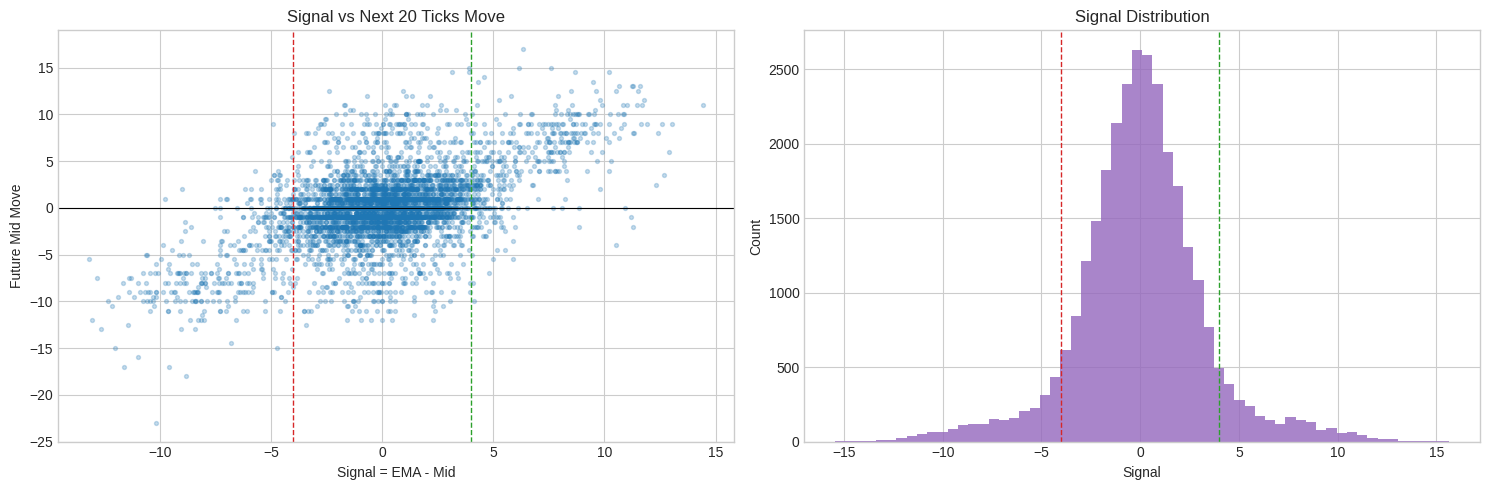

In [6]:
plot_df = ash.dropna(subset=['future_move']).copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sample = plot_df.sample(min(5000, len(plot_df)), random_state=7)
axes[0].scatter(sample['signal'], sample['future_move'], s=8, alpha=0.25, color='tab:blue')
axes[0].axvline(ENTRY_THRESHOLD, color='tab:green', linestyle='--', linewidth=1.0)
axes[0].axvline(-ENTRY_THRESHOLD, color='tab:red', linestyle='--', linewidth=1.0)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title(f'Signal vs Next {FUTURE_HORIZON} Ticks Move')
axes[0].set_xlabel('Signal = EMA - Mid')
axes[0].set_ylabel('Future Mid Move')

axes[1].hist(plot_df['signal'], bins=60, color='tab:purple', alpha=0.8)
axes[1].axvline(ENTRY_THRESHOLD, color='tab:green', linestyle='--', linewidth=1.0)
axes[1].axvline(-ENTRY_THRESHOLD, color='tab:red', linestyle='--', linewidth=1.0)
axes[1].set_title('Signal Distribution')
axes[1].set_xlabel('Signal')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()


In [7]:
bucket_summary = pd.DataFrame(
    {
        'bucket': pd.cut(
            plot_df['signal'],
            bins=[-np.inf, -8, -4, -2, 2, 4, 8, np.inf],
            ordered=True,
        ),
        'future_move': plot_df['future_move'],
    }
)

bucket_summary.groupby('bucket', observed=False)['future_move'].agg(['count', 'mean', 'median']).reset_index()


,bucket,count,mean,median
0,"(-inf, -8.0]",634,-8.453,-8.500
1,"(-8.0, -4.0]",1760,-3.582,-3.000
2,"(-4.0, -2.0]",4005,-0.782,-0.500
3,"(-2.0, 2.0]",17186,-0.032,0.000
4,"(2.0, 4.0]",3984,0.790,1.000
5,"(4.0, 8.0]",1763,3.895,3.500
6,"(8.0, inf]",648,8.442,8.500
